# Processamento de dados: BOLD5000

In [4]:
import os
import re
import gc
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from typing import Tuple, Set
from sklearn.model_selection import train_test_split

# ── Dados brutos BOLD5000 ────────────────────────────────
DATA_DIRS = [
    "/home/al.pedro.alberti/Downloads/14456124"
]
SUBJECTS = ["CSI1"]

# ── Saída (lida pelo main.ipynb como dataset 'bold') ────
BASE_OUTPUT       = "/home/al.pedro.alberti/Downloads/dataset/data"
OUTPUT_DIR_TREINO = os.path.join(BASE_OUTPUT, "processed/train")
OUTPUT_DIR_TESTE  = os.path.join(BASE_OUTPUT, "processed/test")

# BOLD5000 usa imagens COCO train2014 
COCO_ANNOTATIONS = "/mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_4/cnn_final/data_loader/auxiliar/instances_train2014.json"

TARGET_SHAPE = (91, 109, 91)   # mesmo alvo do NSD volumétrico (AVG/IND)
TRS          = ["TR1", "TR2", "TR3", "TR4", "TR5"]
TEST_SIZE    = 0.1
RANDOM_STATE = 42

# ── Rótulos: MESMO esquema do NSD_ROI (process_data_ROI) ────
# Prioridade pessoa > animal > outro, MAS só conta pessoa/animal se a área
# ocupar pelo menos *_MIN_FRAC da imagem (filtra presença incidental).
# Outro só vale se a supercategoria dominante (fora pessoa/animal) estiver em
# OUTRO_SUPERCATS — caso contrário a imagem é DESCARTADA (sem rótulo).
PERSON_MIN_FRAC = 0.02
ANIMAL_MIN_FRAC = 0.02
OUTRO_SUPERCATS = {"vehicle", "furniture", "outdoor"}

NOMES_CLASSES = {0: "Pessoa", 1: "Animal", 2: "Outro"}

CORES = ["#E63946", "#2A9D8F", "#264653"]

# ── Data augmentation ────────────────────────────────────────
# Ruído gaussiano aditivo — a augmentation mais comum em fMRI.
# Cada canal já é z-scored por volume (média 0, desvio 1) em load_trial_channels, então
# AUG_NOISE_SIGMA está em unidades de desvio-padrão do sinal (0.1 ≈ ruído de 10%).
# Só o TREINO é aumentado; o TESTE nunca recebe ruído.

AUG_NOISE_SIGMA = 0.1   # desvio do ruído gaussiano
AUG_FACTOR      = 1     # nº de cópias ruidosas por trial de treino 
AUG_SEED        = RANDOM_STATE
OUTPUT_DIR_TREINO_AUG = os.path.join(BASE_OUTPUT, "processed_aug/train")
OUTPUT_DIR_TESTE_AUG  = os.path.join(BASE_OUTPUT, "processed_aug/test")


def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    """Ruído gaussiano aditivo N(0, sigma) sobre o tensor de entrada. Como X já
    é z-scored por volume, sigma está em unidades de desvio-padrão do sinal."""
    return x + torch.randn_like(x) * sigma


print("[config] Configurações carregadas (rótulos alinhados ao NSD_ROI).")
print(f"[config] Augmentation: ruído gaussiano σ={AUG_NOISE_SIGMA}, "
      f"{AUG_FACTOR} cópia(s)/trial de treino → {OUTPUT_DIR_TREINO_AUG}")


[config] Configurações carregadas (rótulos alinhados ao NSD_ROI).
[config] Augmentation: ruído gaussiano σ=0.1, 1 cópia(s)/trial de treino → /home/al.pedro.alberti/Downloads/dataset/data/processed_aug/train


### Funções Auxiliares

In [5]:
def compute_area_by_supercat(annotations_path):
    """
    Mantém as supercategorias COCO originais (sem colapsar). Retorna:
      area_by_super[img_id][supercat] = área somada das instâncias daquela supercat
      img_area[img_id]                = área total (width*height)
    (idêntico ao process_data_ROI.)
    """
    with open(annotations_path) as f:
        coco_data = json.load(f)

    cat_to_super = {cat["id"]: cat["supercategory"] for cat in coco_data["categories"]}
    img_area = {im["id"]: im["width"] * im["height"] for im in coco_data["images"]}

    area_by_super = defaultdict(lambda: defaultdict(float))
    for ann in coco_data["annotations"]:
        sup = cat_to_super.get(ann["category_id"], "outro")
        area_by_super[ann["image_id"]][sup] += ann["area"]

    return area_by_super, img_area


def plot_supercat_distribution(area_by_super, relevant_coco_ids, titulo="Pool de Sujeitos"):
    """
    Para cada imagem do pool, encontra a supercategoria COCO DOMINANTE (maior
    área somada) e plota a contagem de imagens por supercategoria — uma imagem
    conta uma vez só (pelo dominante), evitando dupla contagem por presença.
    (idêntico ao process_data_ROI.)
    """
    dominant_counts = Counter()
    sem_anotacao = 0
    for cid in relevant_coco_ids:
        supers = area_by_super.get(cid)
        if not supers:
            sem_anotacao += 1
            continue
        dominant = max(supers.items(), key=lambda kv: kv[1])[0]
        dominant_counts[dominant] += 1
    if sem_anotacao:
        dominant_counts["sem anotação"] = sem_anotacao

    items   = sorted(dominant_counts.items(), key=lambda kv: kv[1], reverse=True)
    nomes   = [k for k, _ in items]
    valores = [v for _, v in items]
    total   = sum(valores)

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(nomes, valores, color="#457B9D", edgecolor="black", alpha=0.85)
    ax.set_title(f"Superclasse COCO dominante por imagem — {titulo} (n={total:,})",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Imagens")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=40, ha="right")
    mv = max(valores) if valores else 1
    for b, v in zip(bars, valores):
        ax.text(b.get_x() + b.get_width()/2, v + mv*0.01, f"{v:,}\n({v/total*100:.1f}%)",
                ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    return dominant_counts


def resolve_label(area_by_super, image_area, person_min_frac=0.0, animal_min_frac=0.0, outro_supercats=None):
    """
    Prioridade pessoa > animal > outro, mas só conta pessoa/animal se a área
    ocupar >= *_min_frac da imagem. Outro só vale se a supercategoria dominante
    (fora pessoa/animal) estiver em outro_supercats — senão a imagem é
    DESCARTADA (retorna None). Idêntico ao process_data_ROI.
    """
    if image_area <= 0:
        return None
    person_area = area_by_super.get("person", 0.0)
    animal_area = area_by_super.get("animal", 0.0)
    if person_area > 0 and (person_area / image_area) >= person_min_frac:
        return 0
    if animal_area > 0 and (animal_area / image_area) >= animal_min_frac:
        return 1
    if outro_supercats is None:
        return 2
    outro_areas = {k: v for k, v in area_by_super.items() if k not in ("person", "animal")}
    if not outro_areas:
        return None
    dominant_sup = max(outro_areas.items(), key=lambda kv: kv[1])[0]
    return 2 if dominant_sup in outro_supercats else None


def build_coco_label_map(annotations_path, person_min_frac=0.0, animal_min_frac=0.0, outro_supercats=None):
    """
    coco_id → label (0=pessoa, 1=animal, 2=outro). Imagens descartadas pela
    regra de fração/OUTRO_SUPERCATS NÃO entram no dict (devem ser puladas).
    """
    print(f"[coco] Carregando anotações de: {annotations_path} ...")
    area_by_super, img_area = compute_area_by_supercat(annotations_path)
    labels = {}
    for img_id, areas in area_by_super.items():
        lbl = resolve_label(areas, img_area.get(img_id, 0), person_min_frac, animal_min_frac, outro_supercats)
        if lbl is not None:
            labels[img_id] = lbl
    print(f"[coco] {len(labels):,} imagens rotuladas (após fração/OUTRO_SUPERCATS).")
    return labels


def extract_coco_id(imgname: str) -> int:
    """
    Extrai o image_id numérico do nome do arquivo COCO via regex.
    Ex: 'COCO_train2014_000000420713.jpg' → 420713
    """
    stem    = Path(imgname).stem
    numeros = re.findall(r'\d+', stem)
    if len(numeros) >= 2:
        return int(numeros[1])
    elif len(numeros) == 1:
        return int(numeros[0])
    return -1


def check_data_dir(data_dir: str, subject: str) -> None:
    """Falha cedo e com mensagem clara se os arquivos brutos não estiverem presentes."""
    faltando = []
    img_txt = os.path.join(data_dir, f"{subject}_imgnames.txt")
    if not os.path.exists(img_txt):
        faltando.append(img_txt)
    for tr in TRS:
        nii = os.path.join(data_dir, f"{subject}_SPMResids_allsess_{tr}.nii")
        if not os.path.exists(nii):
            faltando.append(nii)
    if faltando:
        raise FileNotFoundError(
            f"Dados brutos do BOLD5000 ausentes para {subject}:\n  - "
            + "\n  - ".join(faltando)
            + "\n\nBaixe o BOLD5000 (figshare: 6459449) e aponte DATA_DIRS para a "
              "pasta com os arquivos *_imgnames.txt e *_SPMResids_allsess_TR*.nii."
        )


def load_imgnames(data_dir: str, subject: str) -> list:
    """Lê o imgnames.txt e retorna lista de nomes de arquivo por trial."""
    path = os.path.join(data_dir, f"{subject}_imgnames.txt")
    with open(path) as f:
        names = [l.strip() for l in f if l.strip()]
    print(f"[labels] {subject}: {len(names)} trials no total")
    return names


def collect_coco_trials(imgnames: list, image_to_label: dict) -> list:
    """
    Trials cujo estímulo é imagem COCO E que receberam rótulo (não descartados
    pela regra de fração/OUTRO_SUPERCATS). Retorna lista de (trial_idx, coco_id).
    """
    out = []
    for i, name in enumerate(imgnames):
        if not Path(name).stem.startswith("COCO"):
            continue
        cid = extract_coco_id(name)
        if cid in image_to_label:        # descartados não entram
            out.append((i, cid))
    return out


def open_tr_volumes(data_dir: str, subject: str) -> list:
    """
    Abre os 5 arquivos TR UMA vez por sujeito (nib.load é lazy: nada é lido
    do disco ainda). Retorna a lista de proxies; o fatiamento por trial em
    load_trial_channels lê só o volume daquele trial.
    """
    imgs = []
    for tr in TRS:
        path = os.path.join(data_dir, f"{subject}_SPMResids_allsess_{tr}.nii")
        imgs.append(nib.load(path))
    return imgs


def resize_volume(vol: np.ndarray, target: tuple) -> torch.Tensor:
    """Substitui NaN/Inf por 0 e redimensiona (X,Y,Z) → target (trilinear)."""
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    t   = torch.tensor(vol).unsqueeze(0).unsqueeze(0).float()  # (1,1,X,Y,Z)
    t   = F.interpolate(t, size=target, mode='trilinear', align_corners=False)
    return t.squeeze(0).squeeze(0)                             # (91,109,91)


def load_trial_channels(tr_imgs: list, trial_idx: int, target: tuple) -> torch.Tensor:
    """
    Para um trial, lê o volume correspondente de cada TR (já aberto), normaliza
    (z-score por volume) e redimensiona. Retorna tensor (5, 91, 109, 91).
    Memória: lê 5 volumes pequenos por trial, nunca a série 4D inteira.
    """
    channels = []
    for img in tr_imgs:
        trial = np.asarray(img.dataobj[:, :, :, trial_idx], dtype=np.float32)
        trial = np.nan_to_num(trial, nan=0.0, posinf=0.0, neginf=0.0)
        mean, std = trial.mean(), trial.std()
        if std < 1e-8:
            std = 1.0
        trial = (trial - mean) / std
        channels.append(resize_volume(trial, target))
    return torch.stack(channels, dim=0)


def make_split(coco_indices: list, image_to_label: dict) -> Tuple[Set, Set]:
    """
    Split treino/teste por image_id único (não por trial), com stratify.
    Evita leakage de imagens repetidas — mesma estratégia do NSD.
    Retorna dois sets de coco_ids: train_ids, test_ids.
    """
    ids_vistos = {}
    for _, coco_id in coco_indices:
        if coco_id not in ids_vistos:
            ids_vistos[coco_id] = image_to_label[coco_id]

    ids_unicos    = list(ids_vistos.keys())
    labels_unicos = [ids_vistos[cid] for cid in ids_unicos]

    train_ids, test_ids = train_test_split(
        ids_unicos,
        test_size=TEST_SIZE,
        stratify=labels_unicos,
        random_state=RANDOM_STATE,
    )
    print(f"[split] {len(train_ids)} imagens únicas em treino | {len(test_ids)} em teste")
    return set(train_ids), set(test_ids)


def plot_final_distribution(contador_train: Counter, contador_test: Counter, titulo: str = "BOLD5000"):
    """Distribuição final das classes em treino e teste."""
    classes = sorted(NOMES_CLASSES.keys())
    nomes   = [NOMES_CLASSES[c] for c in classes]
    valores_train = [contador_train[c] for c in classes]
    valores_test  = [contador_test[c] for c in classes]

    x = np.arange(len(classes))
    largura = 0.35
    plt.figure(figsize=(10, 6))
    bars_train = plt.bar(x - largura/2, valores_train, largura,
                         color=CORES[:len(classes)], edgecolor="black", alpha=0.9, label="Treino")
    bars_test  = plt.bar(x + largura/2, valores_test, largura,
                         color=CORES[:len(classes)], edgecolor="black", alpha=0.55, label="Teste")
    plt.xticks(x, nomes)
    plt.title(f"Distribuição Semântica — {titulo}", fontsize=14, fontweight="bold")
    plt.ylabel("Número de trials"); plt.xlabel("Classe")
    plt.legend(); plt.grid(axis="y", linestyle="--", alpha=0.5)
    for bars in (bars_train, bars_test):
        for bar in bars:
            h = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}",
                     ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


print("[utils] Funções auxiliares carregadas.")

[utils] Funções auxiliares carregadas.


### Distribuição das classes

[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_4/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 67,020 imagens rotuladas (após fração/OUTRO_SUPERCATS).
[labels] CSI1: 5254 trials no total
[split] 1432 imagens únicas em treino | 160 em teste

[distribuição] 1703 trials rotulados (432 descartados pela regra de fração/OUTRO_SUPERCATS, de 2135 trials COCO)
  classe : total (treino/teste)
  Pessoa :   750 (44.0%)  treino= 679  teste=  71
  Animal :   439 (25.8%)  treino= 395  teste=  44
  Outro  :   514 (30.2%)  treino= 460  teste=  54


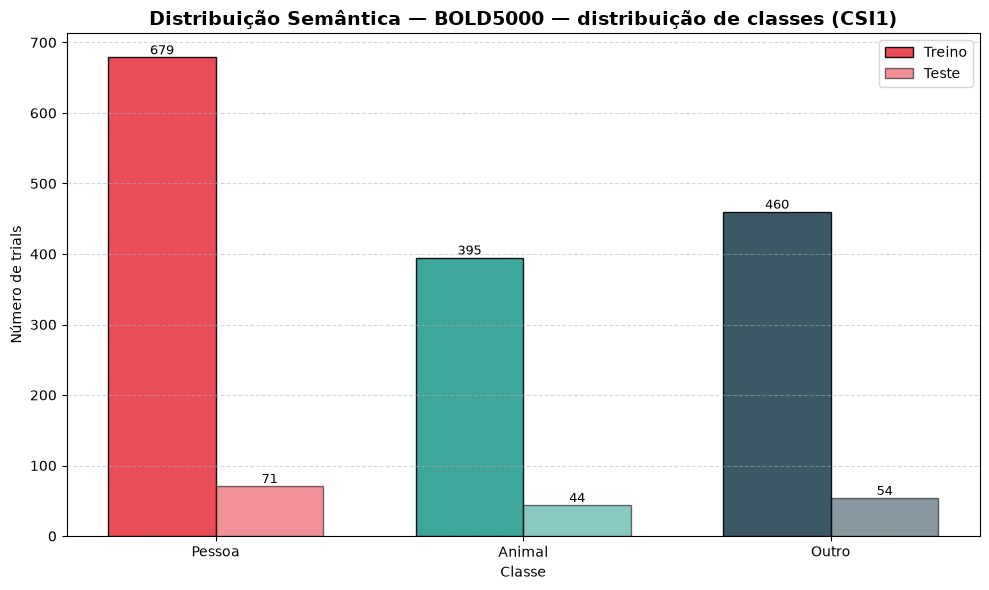

In [6]:
# ── Distribuição das classes (rápido: só rótulos, NÃO carrega os volumes) ─────
# Roda independente do processamento pesado — útil p/ conferir o balanceamento
# das 3 classes (esquema NSD_ROI: fração de área + OUTRO_SUPERCATS) antes de gerar os .p.
image_to_label_dict = build_coco_label_map(
    COCO_ANNOTATIONS,
    person_min_frac=PERSON_MIN_FRAC,
    animal_min_frac=ANIMAL_MIN_FRAC,
    outro_supercats=OUTRO_SUPERCATS,
)

dist_train = Counter()
dist_test  = Counter()
n_coco = n_descartados = 0

for data_dir, subject in zip(DATA_DIRS, SUBJECTS):
    img_txt = os.path.join(data_dir, f"{subject}_imgnames.txt")
    if not os.path.exists(img_txt):
        print(f"[aviso] {img_txt} ausente — pulei {subject} (coloque os dados brutos).")
        continue
    imgnames = load_imgnames(data_dir, subject)
    todos_coco = [extract_coco_id(n) for n in imgnames if Path(n).stem.startswith("COCO")]
    coco_indices = collect_coco_trials(imgnames, image_to_label_dict)  # já dropa descartados
    n_coco        += len(todos_coco)
    n_descartados += len(todos_coco) - len(coco_indices)
    train_ids, test_ids = make_split(coco_indices, image_to_label_dict)
    for _, coco_id in coco_indices:
        y = image_to_label_dict[coco_id]
        (dist_train if coco_id in train_ids else dist_test)[y] += 1

dist_overall = dist_train + dist_test
total = sum(dist_overall.values())
if total:
    print(f"\n[distribuição] {total} trials rotulados "
          f"({n_descartados} descartados pela regra de fração/OUTRO_SUPERCATS, de {n_coco} trials COCO)")
    print("  classe : total (treino/teste)")
    for c in sorted(NOMES_CLASSES):
        n = dist_overall[c]
        print(f"  {NOMES_CLASSES[c]:<7}: {n:5d} ({n/total*100:4.1f}%)  "
              f"treino={dist_train[c]:4d}  teste={dist_test[c]:4d}")
    plot_final_distribution(dist_train, dist_test,
                            "BOLD5000 — distribuição de classes (" + ", ".join(SUBJECTS) + ")")
else:
    print("[distribuição] nenhum trial rotulado (dados brutos ausentes?).")

### Distribuição por hiperclasse COCO

Mesma exploração do `process_data_ROI`: mostra a composição real do pool COCO usado pelo BOLD5000 (as 12 supercategorias originais, uma por imagem pela dominante em área) **antes** do colapso em Pessoa/Animal/Outro — ajuda a entender o que forma a classe "Outro".

[labels] CSI1: 5254 trials no total


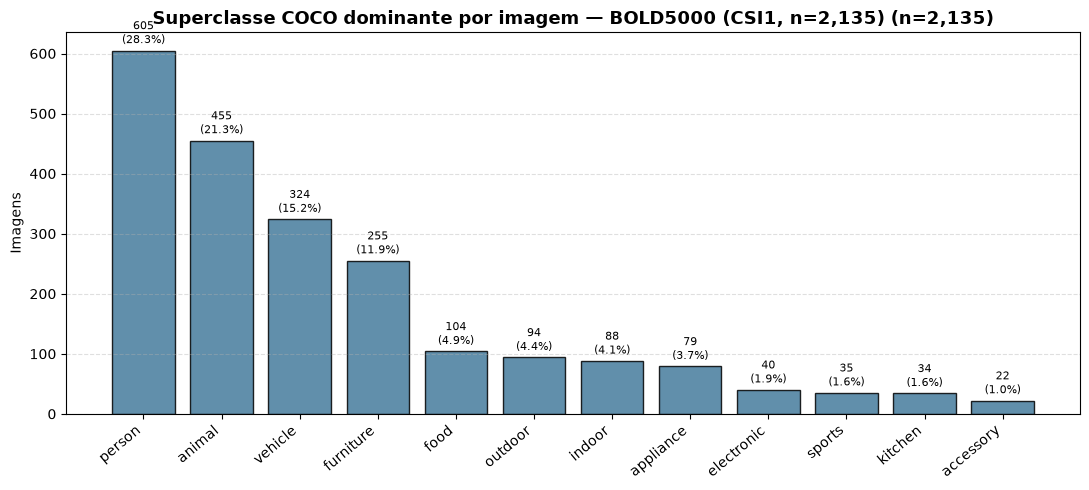

In [7]:
# ── Distribuição por hiperclasse COCO (12 supercategorias originais, dominante por imagem) ──
# Roda independente do processamento pesado — mostra a composição do pool ANTES da
# regra de fração/OUTRO_SUPERCATS (idêntico ao explore de process_data_ROI).
area_by_super_explore, _ = compute_area_by_supercat(COCO_ANNOTATIONS)

relevant_coco_ids = []
for data_dir, subject in zip(DATA_DIRS, SUBJECTS):
    img_txt = os.path.join(data_dir, f"{subject}_imgnames.txt")
    if not os.path.exists(img_txt):
        print(f"[aviso] {img_txt} ausente — pulei {subject} (coloque os dados brutos).")
        continue
    imgnames = load_imgnames(data_dir, subject)
    relevant_coco_ids += [extract_coco_id(n) for n in imgnames if Path(n).stem.startswith("COCO")]

if relevant_coco_ids:
    dominant_counts_explore = plot_supercat_distribution(
        area_by_super_explore, relevant_coco_ids,
        titulo=f"BOLD5000 ({', '.join(SUBJECTS)}, n={len(relevant_coco_ids):,})"
    )
else:
    print("[hiperclasse] nenhum trial COCO encontrado (dados brutos ausentes?).")

### Processamento dos dados 

[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_4/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 67,020 imagens rotuladas (após fração/OUTRO_SUPERCATS).

Processando: CSI1
[labels] CSI1: 5254 trials no total
[filter] 1703 trials COCO rotulados (432 descartados) de 5254 totais
[split] 1432 imagens únicas em treino | 160 em teste
[save] Salvando 1703 arquivos .p...
  [0/1703] y=2 (Outro) | test
  [500/1703] y=2 (Outro) | train
  [1000/1703] y=2 (Outro) | train
  [1500/1703] y=2 (Outro) | train
[done] CSI1

[resumo] treino={0: 679, 2: 460, 1: 395} | teste={2: 54, 1: 44, 0: 71} | 432 trials COCO descartados (fração/OUTRO_SUPERCATS)


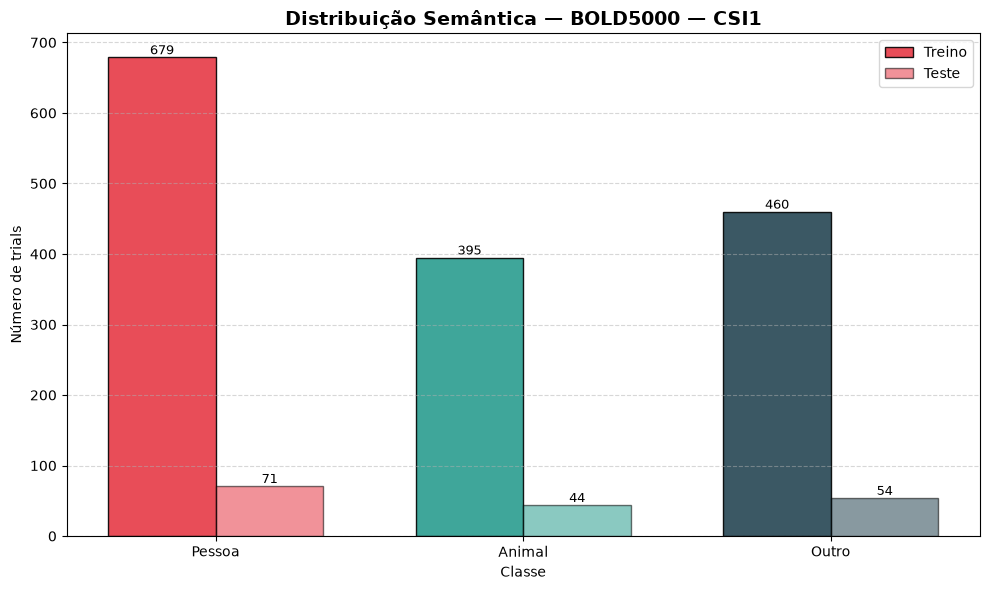

In [10]:
# ── Processamento e salvamento (.p no MESMO FORMATO DO NSD volumétrico) ───────────
# Rótulos pelo esquema NSD_ROI (fração de área + OUTRO_SUPERCATS): imagens que não
# se qualificam são DESCARTADAS (não viram Outro).
image_to_label_dict = build_coco_label_map(
    COCO_ANNOTATIONS,
    person_min_frac=PERSON_MIN_FRAC,
    animal_min_frac=ANIMAL_MIN_FRAC,
    outro_supercats=OUTRO_SUPERCATS,
)

contador_train = Counter()   # acumula em todos os sujeitos
contador_test  = Counter()
n_descartados  = 0           # trials COCO descartados pela regra de rótulo

for data_dir, subject in zip(DATA_DIRS, SUBJECTS):

    check_data_dir(data_dir, subject)   # falha cedo se faltar dado bruto

    out_treino = os.path.join(OUTPUT_DIR_TREINO, subject)
    out_teste  = os.path.join(OUTPUT_DIR_TESTE,  subject)
    os.makedirs(out_treino, exist_ok=True)
    os.makedirs(out_teste,  exist_ok=True)

    print(f"\n{'='*60}\nProcessando: {subject}\n{'='*60}")

    # 1. Nomes de imagem por trial
    imgnames = load_imgnames(data_dir, subject)
    n_trials = len(imgnames)

    # 2. Trials COCO COM rótulo (BOLD5000 mistura COCO/ImageNet/SUN; alguns COCO são descartados)
    n_coco_total = sum(Path(n).stem.startswith("COCO") for n in imgnames)
    coco_indices = collect_coco_trials(imgnames, image_to_label_dict)
    n_descartados += n_coco_total - len(coco_indices)
    print(f"[filter] {len(coco_indices)} trials COCO rotulados "
          f"({n_coco_total - len(coco_indices)} descartados) de {n_trials} totais")

    # 3. Split por image_id único, estratificado (sem leakage)
    train_ids, test_ids = make_split(coco_indices, image_to_label_dict)

    # 4. Abre os 5 TRs UMA vez (lazy) e processa trial a trial
    tr_imgs = open_tr_volumes(data_dir, subject)
    print(f"[save] Salvando {len(coco_indices)} arquivos .p...")
    for trial_num, (i, coco_id) in enumerate(coco_indices):
        y = image_to_label_dict[coco_id]   # garantido presente (collect_coco_trials filtrou)

        X = load_trial_channels(tr_imgs, i, TARGET_SHAPE)   # (5, 91, 109, 91)

        if coco_id in train_ids:
            destino = os.path.join(out_treino, f"trial{trial_num:05d}.p")
            contador_train[y] += 1
        else:
            destino = os.path.join(out_teste, f"trial{trial_num:05d}.p")
            contador_test[y] += 1

        torch.save({
            'X':       X,          # tensor(5, 91, 109, 91)
            'y':       y,          # int (0=Pessoa, 1=Animal, 2=Outro)
            'coco_id': coco_id,    # int (ID numérico COCO)
            'subject': subject,    # str (ex: "CSI1")
        }, destino)

        if trial_num % 500 == 0:
            split_tag = "train" if coco_id in train_ids else "test"
            print(f"  [{trial_num}/{len(coco_indices)}] y={y} ({NOMES_CLASSES[y]}) | {split_tag}")

    del tr_imgs
    gc.collect()
    print(f"[done] {subject}")

print(f"\n[resumo] treino={dict(contador_train)} | teste={dict(contador_test)} "
      f"| {n_descartados} trials COCO descartados (fração/OUTRO_SUPERCATS)")

# Distribuição final (somada em todos os sujeitos)
plot_final_distribution(contador_train, contador_test, "BOLD5000 — " + ", ".join(SUBJECTS))

### Processamento com Data Augmentation (ruído gaussiano)

Opção **alternativa** à célula acima: mesmo pipeline, mas grava em `processed_aug/` e, **só no treino**, adiciona a original + `AUG_FACTOR` cópias com ruído gaussiano N(0, `AUG_NOISE_SIGMA`). O **teste é gravado sem ruído** (métrica honesta). Rode a célula baseline **ou** esta — cada uma gera um dataset independente.

[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_4/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 67,020 imagens rotuladas (após fração/OUTRO_SUPERCATS).

Processando (AUG σ=0.1, x1): CSI1
[labels] CSI1: 5254 trials no total
[filter] 1703 trials COCO rotulados (432 descartados) de 5254 totais
[split] 1432 imagens únicas em treino | 160 em teste
[save] Salvando originais + 1 cópia(s)/trial (ruído só no treino)...
  [0/1703] y=2 (Outro) | test
  [500/1703] y=2 (Outro) | train
  [1000/1703] y=2 (Outro) | train
  [1500/1703] y=2 (Outro) | train
[done] CSI1

[resumo AUG] originais treino={0: 679, 2: 460, 1: 395} | teste={2: 54, 1: 44, 0: 71}
[resumo AUG] 1534 cópias ruidosas gravadas (σ=0.1) | 432 trials COCO descartados
[resumo AUG] treino efetivo = 1534 originais + 1534 aug = 3068 amostras


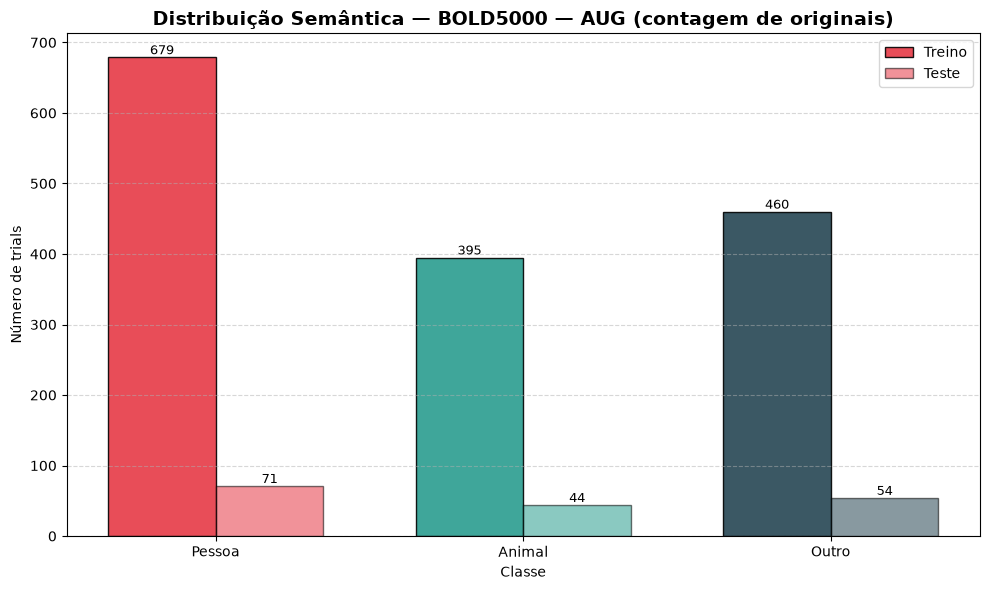

In [11]:
# ── [OPÇÃO ALTERNATIVA] Processamento COM data augmentation (ruído gaussiano) ──
# Mesmo pipeline da célula baseline, porém grava em processed_aug/ e, NO TREINO,
# salva a original + AUG_FACTOR cópias com ruído gaussiano N(0, AUG_NOISE_SIGMA).
# O TESTE é gravado SEM ruído (cópia das originais) → métrica de teste honesta.
# Para treinar com augmentation no main.ipynb, aponte:
#   dataset_path_bold = ".../processed_aug/train/CSI1"   (e o test path em processed_aug/test)
torch.manual_seed(AUG_SEED)

image_to_label_dict = build_coco_label_map(
    COCO_ANNOTATIONS,
    person_min_frac=PERSON_MIN_FRAC,
    animal_min_frac=ANIMAL_MIN_FRAC,
    outro_supercats=OUTRO_SUPERCATS,
)

contador_train = Counter()   # conta SÓ as originais (não as cópias aumentadas)
contador_test  = Counter()
n_aug_escritas = 0           # total de cópias ruidosas gravadas
n_descartados  = 0

for data_dir, subject in zip(DATA_DIRS, SUBJECTS):

    check_data_dir(data_dir, subject)   # falha cedo se faltar dado bruto

    out_treino = os.path.join(OUTPUT_DIR_TREINO_AUG, subject)
    out_teste  = os.path.join(OUTPUT_DIR_TESTE_AUG,  subject)
    os.makedirs(out_treino, exist_ok=True)
    os.makedirs(out_teste,  exist_ok=True)

    print(f"\n{'='*60}\nProcessando (AUG σ={AUG_NOISE_SIGMA}, x{AUG_FACTOR}): {subject}\n{'='*60}")

    # 1. Nomes de imagem por trial
    imgnames = load_imgnames(data_dir, subject)
    n_trials = len(imgnames)

    # 2. Trials COCO COM rótulo
    n_coco_total = sum(Path(n).stem.startswith("COCO") for n in imgnames)
    coco_indices = collect_coco_trials(imgnames, image_to_label_dict)
    n_descartados += n_coco_total - len(coco_indices)
    print(f"[filter] {len(coco_indices)} trials COCO rotulados "
          f"({n_coco_total - len(coco_indices)} descartados) de {n_trials} totais")

    # 3. Split por image_id único, estratificado (sem leakage)
    train_ids, test_ids = make_split(coco_indices, image_to_label_dict)

    # 4. Abre os 5 TRs UMA vez (lazy) e processa trial a trial
    tr_imgs = open_tr_volumes(data_dir, subject)
    print(f"[save] Salvando originais + {AUG_FACTOR} cópia(s)/trial (ruído só no treino)...")
    for trial_num, (i, coco_id) in enumerate(coco_indices):
        y = image_to_label_dict[coco_id]

        X = load_trial_channels(tr_imgs, i, TARGET_SHAPE)   # (5, 91, 109, 91), z-scored

        is_train    = coco_id in train_ids
        destino_dir = out_treino if is_train else out_teste

        # original (sempre — treino e teste)
        torch.save({'X': X, 'y': y, 'coco_id': coco_id, 'subject': subject, 'aug': False},
                   os.path.join(destino_dir, f"trial{trial_num:05d}.p"))
        (contador_train if is_train else contador_test)[y] += 1

        # cópias com ruído — SÓ no treino
        if is_train:
            for k in range(AUG_FACTOR):
                X_aug = add_gaussian_noise(X, AUG_NOISE_SIGMA)
                torch.save({'X': X_aug, 'y': y, 'coco_id': coco_id, 'subject': subject, 'aug': True},
                           os.path.join(destino_dir, f"trial{trial_num:05d}_aug{k}.p"))
                n_aug_escritas += 1

        if trial_num % 500 == 0:
            print(f"  [{trial_num}/{len(coco_indices)}] y={y} ({NOMES_CLASSES[y]}) | "
                  f"{'train' if is_train else 'test'}")

    del tr_imgs
    gc.collect()
    print(f"[done] {subject}")

n_orig_train = sum(contador_train.values())
print(f"\n[resumo AUG] originais treino={dict(contador_train)} | teste={dict(contador_test)}")
print(f"[resumo AUG] {n_aug_escritas} cópias ruidosas gravadas (σ={AUG_NOISE_SIGMA}) | "
      f"{n_descartados} trials COCO descartados")
print(f"[resumo AUG] treino efetivo = {n_orig_train} originais + {n_aug_escritas} aug "
      f"= {n_orig_train + n_aug_escritas} amostras")

# Distribuição final (originais; as cópias aumentadas herdam o mesmo rótulo)
plot_final_distribution(contador_train, contador_test,
                        "BOLD5000 — AUG (contagem de originais)")
